Khách hàng tại node: 4673707531
Tài xế gần nhất được chọn tại node: 10959089043 với quãng đường 854.14m


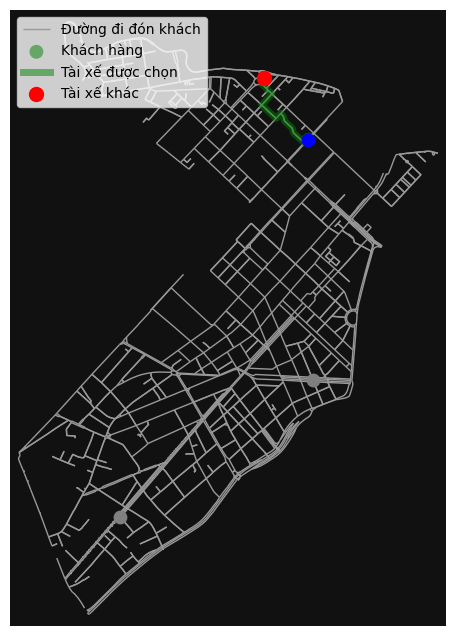

In [19]:
import osmnx as ox
import networkx as nx
import random
import matplotlib.pyplot as plt
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type="drive")

nodes = list(G.nodes)
customer_node = random.choice(nodes)
driver_nodes = random.sample(nodes, 3)

best_driver = None
min_dist = float('inf')
best_route = None

for d_node in driver_nodes:
    try:
        route = nx.shortest_path(G, d_node, customer_node, weight='length')
        dist = nx.shortest_path_length(G, d_node, customer_node, weight='length')

        if dist < min_dist:
            min_dist = dist
            best_driver = d_node
            best_route = route
    except nx.NetworkXNoPath:
        continue

print(f"Khách hàng tại node: {customer_node}")
print(f"Tài xế gần nhất được chọn tại node: {best_driver} với quãng đường {min_dist:.2f}m")

fig, ax = ox.plot_graph_route(G, best_route, route_color='g', route_linewidth=5, node_size=0, show=False, close=False)

c_lat, c_lon = G.nodes[customer_node]['y'], G.nodes[customer_node]['x']
ax.scatter(c_lon, c_lat, c='red', s=100, label='Khách hàng', zorder=5)

for d_node in driver_nodes:
    d_lat, d_lon = G.nodes[d_node]['y'], G.nodes[d_node]['x']
    color = 'blue' if d_node == best_driver else 'gray'
    ax.scatter(d_lon, d_lat, c=color, s=80, label='Tài xế', zorder=5)

plt.legend(['Đường đi đón khách', 'Khách hàng', 'Tài xế được chọn', 'Tài xế khác'])
plt.show()